In [1]:
!pip install protobuf==4.25.3 --force-reinstall
!pip install tensorflow-datasets --upgrade

  Using cached protobuf-4.25.3-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.3-cp37-abi3-manylinux2014_x86_64.whl (294 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-logging 3.16.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-monitoring 2.31.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-pubsub 2.39.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-bigquery-storage 2.39.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
proto-plus 1.28.0 requires protobuf

  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl (327 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-discoveryengine 0.13.12 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protob

In [1]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

print("1. Pobieranie i przygotowywanie danych...")
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

def scale(image, label):
    image = tf.cast(image, tf.float32)
    image /= 255.
    return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))

print("2. Budowanie modelu...")
input_size = 784
output_size = 10
hidden_layer_size = 50

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("3. Rozpoczęcie trenowania...")
NUM_EPOCHS = 30
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(
    train_data,
    epochs=NUM_EPOCHS,
    callbacks=[early_stopping],
    validation_data=(validation_inputs, validation_targets),
    verbose=1
)

print("\n4. Ostateczny test na danych, których model nie widział:")
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy * 100.))

1. Pobieranie i przygotowywanie danych...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.5KH29X_3.0.1/mnist-test.tfrecord-[0-9][0-9][0-9][0-9][0-9…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.
2. Budowanie modelu...
3. Rozpoczęcie trenowania...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8732 - loss: 0.4370 - val_accuracy: 0.9347 - val_loss: 0.2237
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9457 - loss: 0.1837 - val_accuracy: 0.9488 - val_loss: 0.1650
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9611 - loss: 0.1327 - val_accuracy: 0.9535 - val_loss: 0.1467
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9685 - loss: 0.1071 - val_accuracy: 0.9597 - val_loss: 0.1321
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9731 - loss: 0.0899 - val_accuracy: 0.9600 - val_loss: 0.1316
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9764 - loss: 0.0774 - val_accuracy: 0.9662 - val_loss: 0.1127
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9795 - loss: 0.0668 - val_accuracy: 0.9697 - val_loss: 0.1089
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9823 - loss: 0.0596 - val_accuracy: 0.9687 - val

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


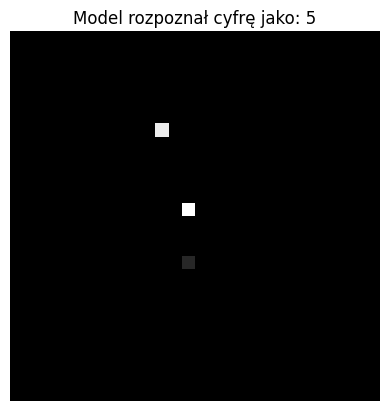


Tablica prawdopodobieństw:
[[0.02  0.06  0.105 0.167 0.071 0.268 0.048 0.044 0.14  0.077]]


In [3]:
# Rozwiązanie Zadania końcowego
nazwa_pliku = 'cyfra.png'

# Wczytanie obrazka z dysku w skali szarości
img = cv2.imread(nazwa_pliku, cv2.IMREAD_GRAYSCALE)

if img is not None:
    # Zbiór MNIST to obrazki 28x28 pikseli, skalujemy nasz plik
    img_resized = cv2.resize(img, (28, 28))

    # Obrazki w MNIST to BIAŁE cyfry na CZARNYM tle.
    # Odwracamy kolory z Painta:
    img_inverted = cv2.bitwise_not(img_resized)

    # Normalizacja (skalowanie wartości z 0-255 do 0-1)
    img_scaled = img_inverted / 255.0

    # Model oczekuje formatu (ilość_próbek, x, y, kanały)
    img_reshaped = img_scaled.reshape(1, 28, 28, 1)

    # Predykcja
    prediction = model.predict(img_reshaped)
    predicted_digit = np.argmax(prediction)

    # Wizualizacja
    plt.imshow(img_inverted, cmap='gray')
    plt.title(f"Model rozpoznał cyfrę jako: {predicted_digit}")
    plt.axis('off')
    plt.show()

    print(f"\nTablica prawdopodobieństw:\n{np.round(prediction, 3)}")
else:
    print(f"Błąd: Nie znaleziono pliku '{nazwa_pliku}'. Wgraj go do Colaba.")